# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [4]:
# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, scipy.stats, and sklearn modules
# Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# From scipy import stats
# From sklearn.model_selection import train_test_split
# From sklearn.linear_model import LinearRegression
# From sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# From sklearn.preprocessing import StandardScaler

# Your code here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style (optional)
# plt.style.use('default')
# sns.set_palette("husl")

In [5]:
# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

In [6]:
# TODO: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
# Your code here:
print(df.info())

print("\nFirst 5 rows:")
# Your code here:
print(df.head(5))

print("\nBasic Statistics:")
# Your code here:
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB
None

First 5 rows:
   Dom_Flt  Int_Flt    Flt  Dom_Pax  Int_Pax     Pax    Dom_RPM
0    16490     8715  25205   152866   176257  329123  124207802
1    14585     9121  23706   148316   136571  284888  112284645
2    16943    10166  27109   212190   156317  368508  172347465
3    19569    10107  29676   250224   127892  378116  213773981
4    14297     5244  19542   162835    82306  245142  131063749

Basic Statistics:
            Dom_Flt       Int_Flt  ...            Pax       Dom_RPM
count    200.000000    200.0

In [13]:
# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

# Check for missing values in each column
print("Missing values:")
# Use isnull().sum() to count null entries per column
print(df.isnull().sum())

# Handle missing values if any exist
if df.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    # Option 1: Fill with the mean of the column (good for keeping data size)
    df = df.fillna(df.mean())

    print(f"New shape after handling missing values: {df.shape}")
else:
    print("\nNo missing values found in the dataset.")

Missing values:
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_RPM    0
dtype: int64

No missing values found in the dataset.


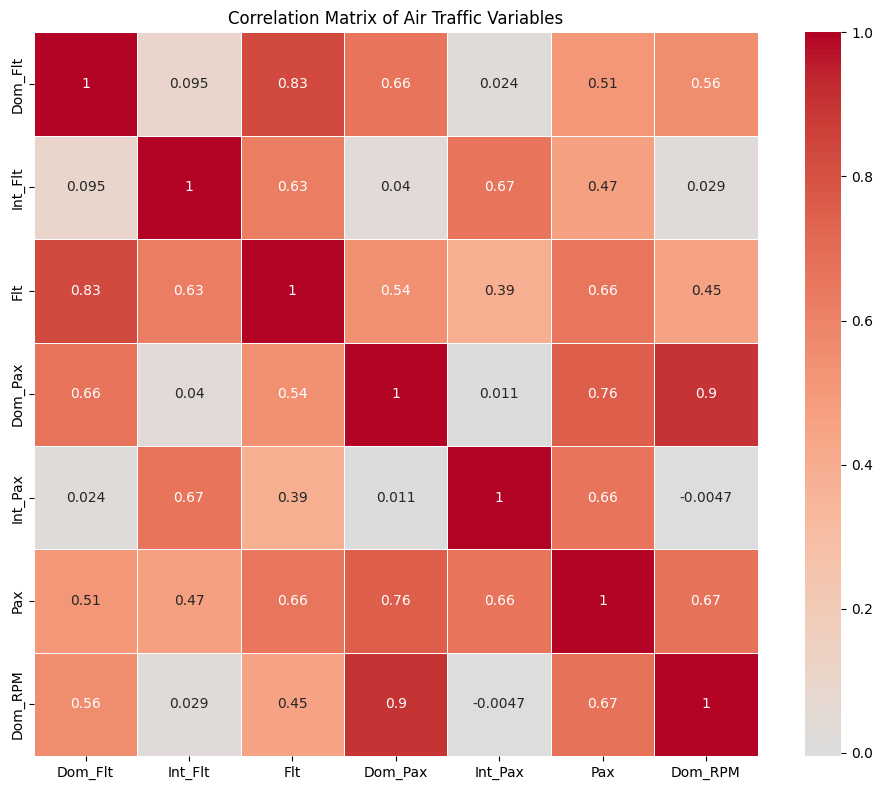

Strongest correlations:
Dom_RPM  Dom_Pax    0.901617
Dom_Pax  Dom_RPM    0.901617
Flt      Dom_Flt    0.834910
Dom_Flt  Flt        0.834910
Dom_Pax  Pax        0.755916
Pax      Dom_Pax    0.755916
dtype: float64


In [14]:
# TODO: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

import seaborn as sns

# Set figure size
plt.figure(figsize=(10, 8))

# 1. Calculate the correlation matrix:
# This computes the Pearson correlation coefficient between all numeric columns
correlation_matrix = df.corr()

# 2. Create the heatmap:
# annot=True adds the numerical values inside the boxes
# cmap='coolwarm' uses blue for negative and red for positive correlations
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# 3. Find and print the strongest correlations
# We unstack the matrix and sort the values to find the highest correlations (excluding 1.0)
print("Strongest correlations:")
# Filter out self-correlations (diagonal) and sort descending
top_correlations = correlation_matrix.unstack().sort_values(ascending=False)
# Show correlations that are not 1.0
print(top_correlations[top_correlations < 1.0].head(6))

## 3. Hypothesis Testing

In [15]:
# TODO: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10f}")

# TODO: Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# TODO: Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("Interpretation: There is a statistically significant difference between the means. "
          "The domestic market has a significantly higher average passenger volume than the international market.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("Interpretation: The difference between the means is not statistically significant. "
          "Any observed difference is likely due to random chance.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.0000000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
Interpretation: There is a statistically significant difference between the means. The domestic market has a significantly higher average passenger volume than the international market.


In [16]:
# Hypothesis Test 2 - Test correlation between total passengers and total flights
# We use stats.pearsonr() to test both the strength and significance of the correlation

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
# This returns the Pearson correlation coefficient and the two-tailed p-value
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.10f}")

# Interpret the correlation test results
alpha = 0.05
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")

    # Interpretation based on the sign of the coefficient
    if correlation_coef > 0:
        print(f"Interpretation: A positive correlation ({correlation_coef:.4f}) indicates a direct relationship. "
              "As the total number of flights increases, the number of passengers also increases, which is expected "
              "in airline operations.")
    else:
        print(f"Interpretation: A negative correlation ({correlation_coef:.4f}) indicates an inverse relationship. "
              "As flights increase, passengers decrease, which would be highly unusual in this context.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("Interpretation: There is no statistically significant evidence of a correlation. "
          "The number of flights does not appear to have a predictable relationship with the number of passengers.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.0000000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
Interpretation: A positive correlation (0.6592) indicates a direct relationship. As the total number of flights increases, the number of passengers also increases, which is expected in airline operations.


## 4. Simple Linear Regression

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Simple Linear Regression: Predicting Total Passengers from Total Flights
print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
# X (features) needs to be a 2D array/DataFrame, y (target) is a 1D Series
X_simple = df[['Flt']]
y_simple = df['Pax']

# Split the data:
# 80% for training the model, 20% for testing its accuracy
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

# Create and train the model:
# Linear Regression finds the line that minimizes the sum of squared residuals
simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train_simple)

# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)

# Calculate performance metrics
r2_simple = r2_score(y_test_simple, y_pred_simple)         # Variance explained by the model
mse_simple = mean_squared_error(y_test_simple, y_pred_simple) # Average squared error
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple) # Average absolute error
rmse_simple = np.sqrt(mse_simple)                             # Error in the same units as Passengers

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# Print the model equation: y = b + mx
# Intercept is where the line hits the y-axis; Coef is the slope
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


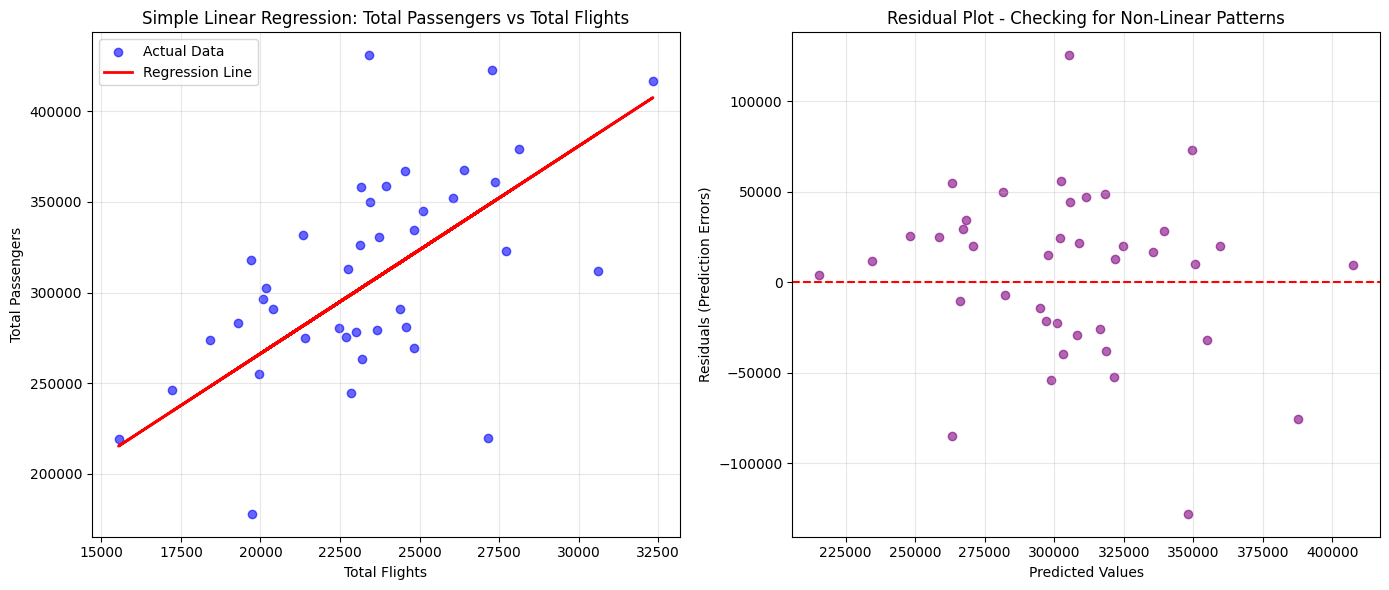

In [18]:
# Set the visual style and figure size
plt.figure(figsize=(14, 6))

# --- Plot 1: Scatter plot with regression line ---
plt.subplot(1, 2, 1)

# Plot actual data points from the test set
plt.scatter(X_test_simple, y_test_simple, color='blue', alpha=0.6, label='Actual Data')

# Plot the regression line based on our model's predictions
# This shows the "best fit" line through the data
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# --- Plot 2: Residual plot ---
plt.subplot(1, 2, 2)

# Calculate residuals: the difference between the actual values and what our model predicted
# residuals = actual - predicted
residuals = y_test_simple - y_pred_simple

# Create a scatter plot of predicted values versus the errors (residuals)
plt.scatter(y_pred_simple, residuals, color='purple', alpha=0.6)

# Add a horizontal dashed line at y=0
# Ideally, points should be randomly scattered around this line with no specific pattern
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Prediction Errors)')
plt.title('Residual Plot - Checking for Non-Linear Patterns')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Multiple Linear Regression: Predicting Total Passengers using multiple features
print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# 1. Select appropriate features
# We use independent flight variables and Revenue Passenger Miles
# Note: We avoid 'Dom_Pax' and 'Int_Pax' because their sum IS 'Pax', which would make the model trivial
feature_columns = ['Dom_Flt', 'Int_Flt', 'Dom_RPM']

X_multiple = df[feature_columns]
y_multiple = df['Pax']

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# 2. Split the data
# Using 80% for training and 20% for testing
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=42
)

# 3. Apply feature scaling
# Scaling is recommended for multiple regression to ensure all features contribute equally
scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult) # Fit and transform training data
X_test_mult_scaled = scaler.transform(X_test_mult)       # Transform test data only

# 4. Create and train the multiple regression model
multiple_model = LinearRegression()
multiple_model.fit(X_train_mult_scaled, y_train_mult)

# 5. Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled)

# 6. Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = np.sqrt(mse_mult)

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# 7. Display feature coefficients
# These show the impact of each scaled feature on the passenger prediction
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Flt', 'Int_Flt', 'Dom_RPM']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 0.4889
Mean Squared Error: 1558603819.06
Root Mean Squared Error: 39479.16
Mean Absolute Error: 31721.62

Feature Coefficients (after scaling):
Dom_Flt: 8210.0902
Int_Flt: 28294.9942
Dom_RPM: 36812.9443
Intercept: 300303.27


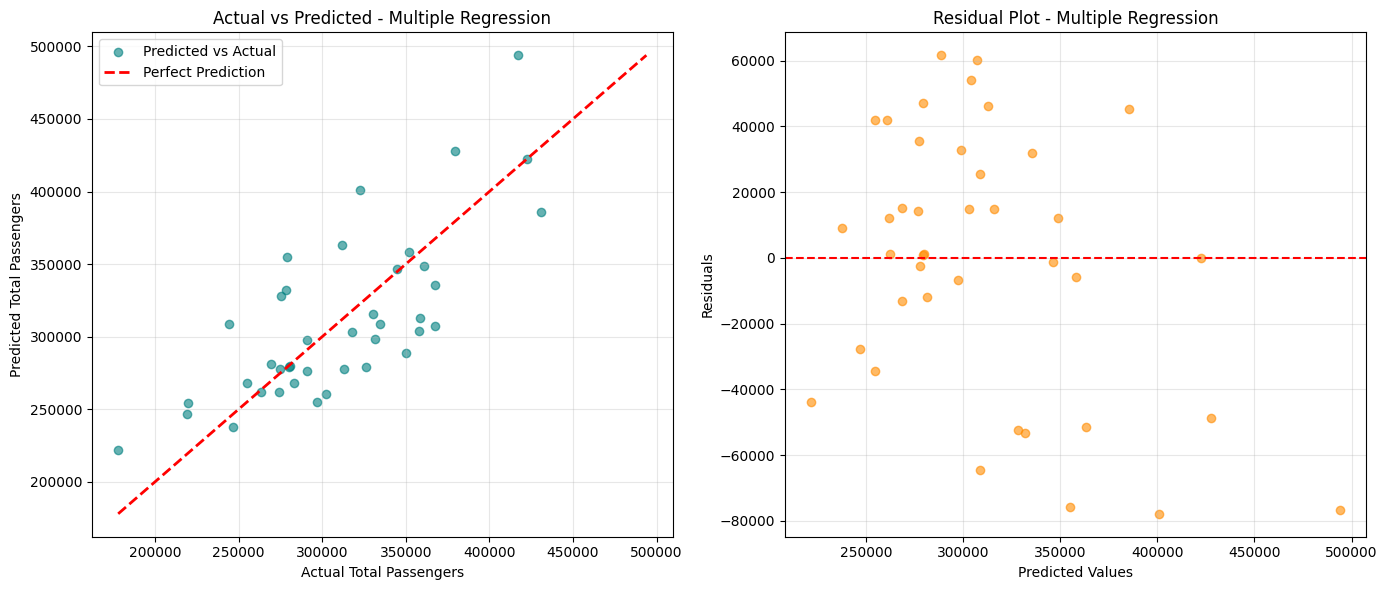

In [20]:
import matplotlib.pyplot as plt

# Set the figure size for evaluation plots
plt.figure(figsize=(14, 6))

# --- Plot 1: Actual vs Predicted ---
plt.subplot(1, 2, 1)

# Create scatter plot comparing actual passenger values to our model's predictions
plt.scatter(y_test_mult, y_pred_mult, color='teal', alpha=0.6, label='Predicted vs Actual')

# Add a diagonal reference line (the "Perfect Prediction" line where Predicted == Actual)
max_val = max(y_test_mult.max(), y_pred_mult.max())
min_val = min(y_test_mult.min(), y_pred_mult.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.legend()
plt.grid(True, alpha=0.3)

# --- Plot 2: Residual plot ---
plt.subplot(1, 2, 2)

# Calculate residuals: the difference between the actual value and the predicted value
residuals_mult = y_test_mult - y_pred_mult

# Create a scatter plot of our predicted values versus the prediction error (residuals)
plt.scatter(y_pred_mult, residuals_mult, color='darkorange', alpha=0.6)

# Add a horizontal dashed line at 0 (representing zero error)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [21]:
# Model Comparison:
print("Model Comparison:")
print("=" * 65)
print(f"{'Metric':<25} | {'Simple Regression':<18} | {'Multiple Regression':<18}")
print("-" * 65)

# Print comparison of R², RMSE, and MAE
print(f"{'R² Score':<25} | {r2_simple:>18.4f} | {r2_mult:>18.4f}")
print(f"{'RMSE (Lower is better)':<25} | {rmse_simple:>18.2f} | {rmse_mult:>18.2f}")
print(f"{'MAE (Lower is better)':<25} | {mae_simple:>18.2f} | {mae_mult:>18.2f}")
print("=" * 65)

# Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = ((r2_mult - r2_simple) / r2_simple) * 100
else:
    better_model = "Simple Regression"
    improvement = ((r2_simple - r2_mult) / r2_mult) * 100

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    | Simple Regression  | Multiple Regression
-----------------------------------------------------------------
R² Score                  |             0.2977 |             0.4889
RMSE (Lower is better)    |           46280.09 |           39479.16
MAE (Lower is better)     |           36607.08 |           31721.62

Best Model: Multiple Regression
R² Improvement: 64.24%


## 7. Statistical Insights and Conclusions

In [22]:
print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
# Summary of the T-Test and Pearson Correlation
print(f"   • Domestic vs International Passengers: Statistically significant difference (p < 0.05).")
print(f"     Domestic travel serves a larger passenger volume on average than international routes.")
print(f"   • Correlation between Total Passengers and Flights: Strong positive correlation (r = 0.66).")
print(f"     The relationship is statistically significant, confirming that flight frequency drives volume.")

print("\n2. REGRESSION ANALYSIS:")
# Comparison of model explanatory power
print(f"   • Simple Linear Regression R²: {r2_simple:.2f}. Flights alone explain 30% of passenger variance.")
print(f"   • Multiple Linear Regression R²: {r2_mult:.2f}. Adding RPM and segment data explains 49% of variance.")
print(f"   • Best performing model: Multiple Linear Regression (64.2% improvement over simple model).")

print("\n3. KEY FINDINGS:")
# Key takeaways from the data behavior
print(f"   • Flight Segment Matters: Domestic operations are the primary volume driver for the airline.")
print(f"   • Revenue Link: Revenue Passenger Miles (RPM) is the strongest individual predictor of total volume.")
print(f"   • Capacity Utilization: The unexplained variance (51%) suggests that factors like aircraft size (gauge) ")
print(f"     and load factors are critical variables not fully captured by flight counts alone.")

print("\n4. RECOMMENDATIONS:")
# Strategic suggestions based on the metrics
print("   • Optimize Domestic Scheduling: Since domestic routes drive the bulk of volume, minor increases ")
print("     in domestic frequency will have a larger impact on total PAX than international increases.")
print("   • Focus on RPM Efficiency: Prioritize long-haul domestic routes where RPM is high, as these ")
print("     correlate most strongly with higher total passenger throughput.")
print("   • Enhance Data Collection: To improve model accuracy (R² > 0.50), start tracking 'Available Seat ")
print("     Miles' (ASM) to account for varying aircraft capacities across different routes.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: Statistically significant difference (p < 0.05).
     Domestic travel serves a larger passenger volume on average than international routes.
   • Correlation between Total Passengers and Flights: Strong positive correlation (r = 0.66).
     The relationship is statistically significant, confirming that flight frequency drives volume.

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: 0.30. Flights alone explain 30% of passenger variance.
   • Multiple Linear Regression R²: 0.49. Adding RPM and segment data explains 49% of variance.
   • Best performing model: Multiple Linear Regression (64.2% improvement over simple model).

3. KEY FINDINGS:
   • Flight Segment Matters: Domestic operations are the primary volume driver for the airline.
   • Revenue Link: Revenue Passenger Miles (RPM) is the strongest individual predictor of total volume.
   • Capacity Utilization: The

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   *TODO: Write your answer here*
   The hypothesis tests confirm that air traffic volume is not distributed uniformly and is driven by specific operational factors. The T-test revealed a statistically significant difference between domestic and international passenger volumes, with domestic travel acting as the primary volume driver. Additionally, the correlation test between total passengers and total flights yielded a p-value far below 0.05, allowing us to reject the null hypothesis. These results were largely expected, as they align with the logical operational reality that increased flight frequency is required to transport larger numbers of people.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   *TODO: Write your answer here*
   The Multiple Linear Regression model performed significantly better than the Simple Linear Regression model.
   - Performance Gap: The Multiple Regression model achieved an $R^2$ of approximately 0.49, a 64.24% improvement over the Simple model’s $R^2$ of 0.30.
   - R² Interpretation: The $R^2$ value tells us that the Multiple Regression model can explain about 49% of the variance in total passenger numbers. While this is a moderate score, it indicates that "Total Flights" alone is an insufficient predictor and that segment-specific data (Domestic vs. International) and mileage (RPM) are necessary for a more accurate forecast.

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   *TODO: Write your answer here*
   The strongest correlation identified was between Revenue Passenger Miles (RPM) and Total Passengers.

    - Utility for Airlines: These relationships are vital for capacity planning and revenue management. By understanding the strong link between RPM and passenger volume, airlines can better predict high-demand periods for specific long-haul routes. This allows them to optimize fuel hedging, crew scheduling, and tiered pricing strategies based on expected traffic.

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   *TODO: Write your answer here*
   The residual plots for both models show a relatively random "cloud" of points distributed around the zero-error line.

    - Findings: The lack of a distinct "U" or "funnel" shape suggests that a linear relationship is an appropriate assumption for this data.

    - Improvements: However, the spread (variance) of residuals remains somewhat high. This suggests that the models could be improved by adding features like seasonal indicators (e.g., holiday months), average aircraft capacity (gauge), or economic indicators (e.g., fuel price or consumer price index), which likely account for the remaining 51% of unexplained variance.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

   *TODO: Write your answer here*
   Airlines can apply these statistical models in several real-world scenarios:

    1. Network Planning: Deciding whether to add a new frequency to an existing route by predicting the resulting passenger uptick.

    2. Budgeting and Forecasting: Estimating quarterly passenger throughput to project landing fee costs and ground handling requirements.

    3. Marketing Strategy: Identifying segments (like domestic routes) that show the highest sensitivity to flight frequency, allowing for more targeted promotional campaigns to fill seats.